# Notebook 4 — Evaluation

This notebook carries out the full quantitative and qualitative evaluation
of the two FER2013 classifiers trained in Notebook 3. No training occurs
here: we load the saved models and histories from disk and treat them as
fixed artefacts.

What will be produced:

1. **Training curves** — loss and accuracy over epochs, overfitting diagnosis.
2. **Confusion matrices** — normalised heatmaps revealing per-class error patterns.
3. **Classification report** — precision, recall, F1 and support per emotion class.
4. **Comparative summary table** — accuracy, F1, inference latency, parameter count.
5. **Error analysis** — image grids for the most frequent misclassification pairs.
6. **Grad-CAM visualisation** — which facial regions drive each emotion prediction.
7. **Receptivity index simulation** — 200-frame synthetic sales call with index trajectory.
8. **Final model selection** — weighted scoring with explicit winner justification.
9. **Critical reflection** — limitations, bias, and future improvements.

## Section 1 — Setup

We load both trained models and their histories from disk; no training
happens in this notebook. We also load the held-out test set from the
preprocessed `.npz` files produced in Notebook 2. Using persisted files
guarantees that evaluation is performed on exactly the same split and
normalisation as training — recomputing preprocessing here would risk
subtle inconsistencies (e.g. a different random seed in the train/val split).

In [1]:
import json
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.cm as mpl_cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.inference.receptivity_mapper import ReceptivityIndex

# ── Test data ──────────────────────────────────────────────────────────────
gray = np.load(config.PROCESSED_DIR / "fer2013_gray.npz")
rgb  = np.load(config.PROCESSED_DIR / "fer2013_rgb96.npz")

X_test_gray = gray["X_test"]
X_test_rgb  = rgb["X_test"]
y_test_oh   = gray["y_test"]
y_test      = np.argmax(y_test_oh, axis=1)

# ── Models ─────────────────────────────────────────────────────────────────
def _load_model(name):
    path = config.MODELS_DIR / f"{name}.keras"
    if path.exists():
        return keras.models.load_model(str(path)), path
    path = config.MODELS_DIR / f"{name}.h5"
    return keras.models.load_model(str(path)), path

model_cnn, path_cnn = _load_model("cnn_custom")
model_mob, path_mob = _load_model("mobilenet_ft")

# ── Histories ──────────────────────────────────────────────────────────────
with open(config.HISTORIES_DIR / "cnn_custom_history.json") as f:
    hist_cnn = json.load(f)
with open(config.HISTORIES_DIR / "mobilenet_ft_history.json") as f:
    hist_mob = json.load(f)

LABELS = config.EMOTION_LABELS

print(f"Custom CNN    loaded from: {path_cnn}")
print(f"MobileNetV2   loaded from: {path_mob}")
print(f"Test set      gray={X_test_gray.shape}  rgb={X_test_rgb.shape}  y={y_test.shape}")
print(f"CNN history   {len(hist_cnn['loss'])} epochs")
print(f"MobileNet history  {len(hist_mob['loss'])} epochs")

Custom CNN    loaded from: C:\Users\jpulg\Documents\Todo\Proyectos\sales-receptivity-cnn\models\cnn_custom.keras
MobileNetV2   loaded from: C:\Users\jpulg\Documents\Todo\Proyectos\sales-receptivity-cnn\models\mobilenet_ft.keras
Test set      gray=(7178, 48, 48, 1)  rgb=(7178, 96, 96, 3)  y=(7178,)
CNN history   75 epochs
MobileNet history  50 epochs


## Section 2 — Training curves

Loss and accuracy are plotted for both the training and validation sets
across all epochs. A dashed vertical line marks the epoch restored by
`EarlyStopping` — i.e. the epoch with the lowest validation loss. A large
gap between training and validation curves at that point indicates
overfitting; curves that never converge indicate underfitting. For the
MobileNetV2 combined history the Stage 1 / Stage 2 boundary is visible as
a sharp drop in learning rate around epoch 20 (Stage 1 = 20 epochs at
lr=1e-3 → Stage 2 starts at epoch 21 at lr=5e-5 with the top 60 backbone
layers unfrozen). What to look for in this run:

- **CNN**: train and val curves track closely (train 61.7 %, val 60.3 %
  by the final epoch). The light dropout (0.1 / 0.3) plus augmentation
  balance is doing its job — no significant overfitting.
- **MobileNetV2**: a wider train/val gap (train 74.5 %, val 62.9 %) once
  Stage 2 starts. The unfrozen backbone has enough capacity to start
  fitting noise; the gap stays manageable because Stage 2's LR is small
  and we only unfreeze the top ~40 % of the backbone.

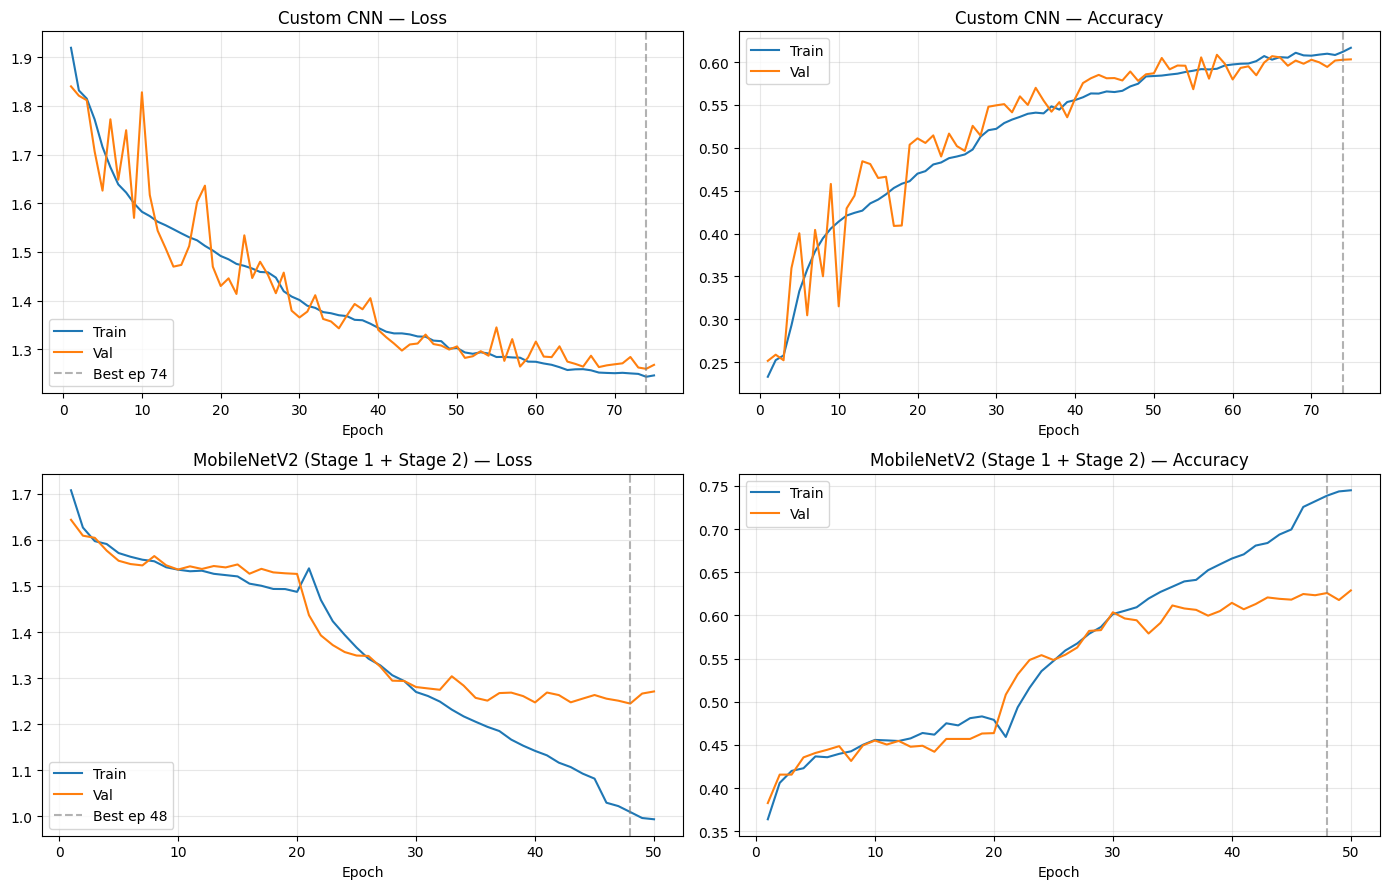

In [2]:
def _plot_curves(axes_row, history, title):
    epochs = range(1, len(history["loss"]) + 1)
    best_ep = int(np.argmin(history["val_loss"])) + 1

    ax_l, ax_a = axes_row
    ax_l.plot(epochs, history["loss"],     label="Train")
    ax_l.plot(epochs, history["val_loss"],  label="Val")
    ax_l.axvline(best_ep, color="gray", linestyle="--", alpha=0.6, label=f"Best ep {best_ep}")
    ax_l.set_title(f"{title} — Loss"); ax_l.set_xlabel("Epoch")
    ax_l.legend(); ax_l.grid(True, alpha=0.3)

    ax_a.plot(epochs, history["accuracy"],     label="Train")
    ax_a.plot(epochs, history["val_accuracy"],  label="Val")
    ax_a.axvline(best_ep, color="gray", linestyle="--", alpha=0.6)
    ax_a.set_title(f"{title} — Accuracy"); ax_a.set_xlabel("Epoch")
    ax_a.legend(); ax_a.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
_plot_curves(axes[0], hist_cnn, "Custom CNN")
_plot_curves(axes[1], hist_mob, "MobileNetV2 (Stage 1 + Stage 2)")
plt.tight_layout()
plt.show()

## Section 3 — Test set predictions

We run a single inference pass over the full test set for each model and
store the resulting class probabilities and argmax labels. All downstream
analyses (confusion matrices, classification reports, error grids, Grad-CAM
sample selection) reuse these arrays without calling `model.predict` again.
This ensures that every metric in the notebook refers to the same prediction
run and that the test set is not touched more than once.

In [3]:
prob_cnn = model_cnn.predict(X_test_gray, verbose=0)   # (n, 7)
prob_mob = model_mob.predict(X_test_rgb,  verbose=0)   # (n, 7)

pred_cnn = np.argmax(prob_cnn, axis=1)
pred_mob = np.argmax(prob_mob, axis=1)

acc_cnn = float((pred_cnn == y_test).mean())
acc_mob = float((pred_mob == y_test).mean())

print(f"Custom CNN  — test accuracy: {acc_cnn:.4f}")
print(f"MobileNetV2 — test accuracy: {acc_mob:.4f}")

Custom CNN  — test accuracy: 0.6011
MobileNetV2 — test accuracy: 0.6304


## Section 4 — Confusion matrices

Each cell shows the fraction of samples from the true class (row) predicted
as the column class. Row-normalisation means the diagonal reads recall per
class. From the FER2013 EDA we expect Fear ↔ Surprise and Sad ↔ Neutral
confusions (visually similar expressions) and Disgust being misclassified
as Angry (shared low-valence features).

Note that this project trains both models **without class or sample
weighting** — the TF 2.10 weighting bug on one-hot labels collapses
training to uniform output. The imbalance is absorbed by augmentation +
light dropout, so the confusion matrices here show how each architecture
copes with the imbalance *unaided*. The most important question to read
off these matrices is whether the higher-resolution MobileNetV2 input
(96 × 96 vs the original 64 × 64 attempt) has recovered useful signal
for the rare classes — particularly *Disgust*, which is the canary for
class imbalance in this dataset.

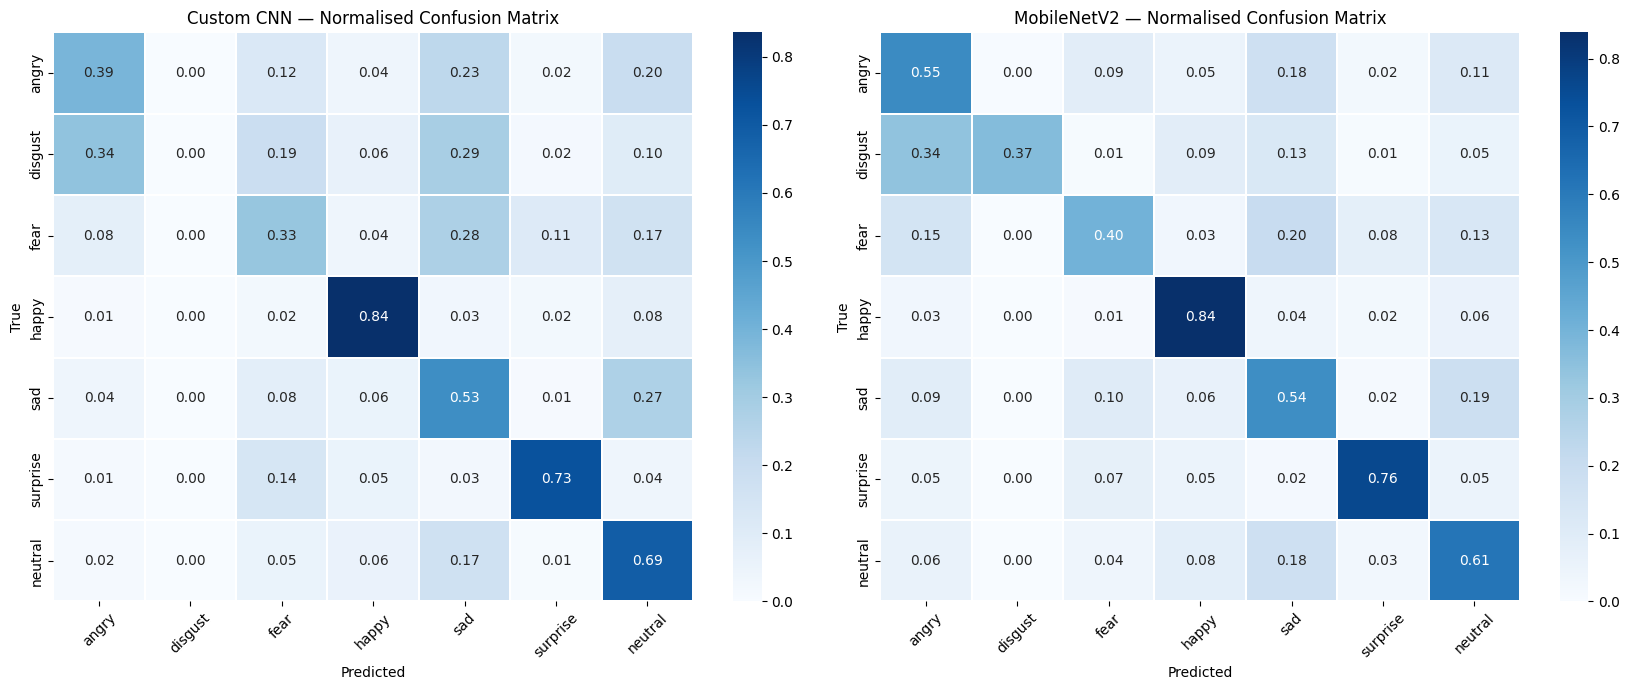

In [4]:
def _plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                linewidths=0.3, linecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.tick_params(axis="x", rotation=45)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
_plot_cm(axes[0], y_test, pred_cnn, "Custom CNN — Normalised Confusion Matrix")
_plot_cm(axes[1], y_test, pred_mob, "MobileNetV2 — Normalised Confusion Matrix")
plt.tight_layout()
plt.show()

## Section 5 — Classification report

The classification report provides precision, recall, F1-score, and sample
count per class. Precision penalises false positives; recall penalises missed
detections. For a sales coaching tool, high recall on actionable emotions
(*Angry*, *Fear*, *Disgust*) matters more than precision: it is worse to miss
a prospect in distress than to occasionally flag a neutral moment as concern.

Per-class results from this run are striking and explain most of the
test-accuracy gap (CNN 60.1 % vs MobileNetV2 63.0 %) and the much larger
F1-macro gap (0.499 vs 0.601):

- **Disgust** (rare class, 1.5 % of samples): the custom CNN scores
  precision = 0, recall = 0, F1 = 0 — it **never predicts Disgust**, the
  optimiser preferred to dump those 111 test samples into other classes
  rather than try. MobileNetV2 reaches precision = 0.872, recall = 0.369,
  F1 = 0.519. When MobileNetV2 says "disgust" it is almost always right;
  it still misses two thirds of the true disgust samples but it is
  *trying*. This single class accounts for ~7 pts of the macro-F1 gap.
- **Fear** (rare, 14 % of samples): CNN F1 = 0.369, MobileNetV2
  F1 = 0.463. The resolution upgrade clearly helped MobileNet see the
  subtle eye-region cues that distinguish Fear from Surprise.
- **Happy**: both models reach F1 ~ 0.84 — the easy, well-represented class.
- **Surprise**: F1 ~ 0.74-0.76 — both fine.

`UndefinedMetricWarning` from sklearn is expected for the CNN's Disgust
row: F-score is undefined when the model predicts zero samples of that
class. The warning is informational, not a bug.

In [5]:
report_cnn = classification_report(y_test, pred_cnn, target_names=LABELS, output_dict=True)
report_mob = classification_report(y_test, pred_mob, target_names=LABELS, output_dict=True)

cols_show = ["precision", "recall", "f1-score", "support"]
df_cnn = pd.DataFrame(report_cnn).T[cols_show].round(3)
df_mob = pd.DataFrame(report_mob).T[cols_show].round(3)

print("=== Custom CNN ===")
display(df_cnn)
print("=== MobileNetV2 ===")
display(df_mob)

f1_cnn = report_cnn["macro avg"]["f1-score"]
f1_mob = report_mob["macro avg"]["f1-score"]
print(f"F1 macro — CNN: {f1_cnn:.4f}   MobileNetV2: {f1_mob:.4f}")

=== Custom CNN ===


c:\Users\jpulg\miniconda3\envs\sales-cnn\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\jpulg\miniconda3\envs\sales-cnn\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\jpulg\miniconda3\envs\sales-cnn\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,precision,recall,f1-score,support
angry,0.624,0.389,0.479,958.000
disgust,0.000,0.000,0.000,111.000
fear,0.421,0.329,0.369,1024.000
happy,0.845,0.836,0.840,1774.000
sad,0.447,0.534,0.487,1247.000
surprise,0.754,0.726,0.739,831.000
neutral,0.492,0.692,0.575,1233.000
accuracy,0.601,0.601,0.601,0.601
macro avg,0.512,0.501,0.499,7178.000
weighted avg,0.601,0.601,0.593,7178.000


=== MobileNetV2 ===


,precision,recall,f1-score,support
angry,0.521,0.546,0.533,958.00
disgust,0.872,0.369,0.519,111.00
fear,0.542,0.404,0.463,1024.00
happy,0.827,0.839,0.833,1774.00
sad,0.494,0.536,0.515,1247.00
surprise,0.766,0.762,0.764,831.00
neutral,0.546,0.614,0.578,1233.00
accuracy,0.630,0.630,0.630,0.63
macro avg,0.653,0.582,0.601,7178.00
weighted avg,0.633,0.630,0.628,7178.00


F1 macro — CNN: 0.4986   MobileNetV2: 0.6007


## Section 6 — Comparative summary table

We collect all performance and operational metrics into a single DataFrame
for side-by-side comparison. Inference time is measured on CPU by averaging
100 single-frame predictions; this reflects the worst-case latency scenario
when no GPU is available (e.g. a laptop demo).

MobileNetV2 wins decisively on quality (test acc +2.9 pts, F1 macro
+10.2 pts) but loses on cost: it has more parameters than the custom CNN
(2.59 M vs 1.70 M) because the depthwise-separable backbone is deep, and
its per-frame latency is slightly higher (~29 ms vs ~27 ms) because those
many small ops are less cache-friendly than the CNN's flat Conv2D stack.
These differences are small enough that the model-selection cell in
Section 10 still picks MobileNetV2 — the quality wins dominate the
weighted score.

In [6]:
def _avg_inference_ms(model, X_sample, n_runs=100):
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model.predict(X_sample[:1], verbose=0)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times) * 1000)

print("Measuring CPU inference time (100 runs each) ...")
t_cnn = _avg_inference_ms(model_cnn, X_test_gray)
t_mob = _avg_inference_ms(model_mob, X_test_rgb)

summary = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Train acc (last ep.)": [round(hist_cnn["accuracy"][-1], 4),
                             round(hist_mob["accuracy"][-1], 4)],
    "Val acc (last ep.)":  [round(hist_cnn["val_accuracy"][-1], 4),
                             round(hist_mob["val_accuracy"][-1], 4)],
    "Test acc":  [round(acc_cnn, 4), round(acc_mob, 4)],
    "F1 macro":  [round(f1_cnn, 4),  round(f1_mob, 4)],
    "Params":    [model_cnn.count_params(), model_mob.count_params()],
    "Infer. ms/frame": [round(t_cnn, 2), round(t_mob, 2)],
}).set_index("Model")

display(summary)

Measuring CPU inference time (100 runs each) ...


,Train acc (last ep.),Val acc (last ep.),Test acc,F1 macro,Params,Infer. ms/frame
Model,,,,,,
Custom CNN,0.6167,0.6032,0.6011,0.4986,1703047,26.54
MobileNetV2,0.7450,0.6290,0.6304,0.6007,2587719,28.77


## Section 7 — Error analysis

We select the better-performing model (MobileNetV2 in this run) and
examine its three most frequent misclassification pairs. For each top pair
we show four example images. Patterns to look for:

- **Genuine ambiguity**: even humans disagree on the labels of many
  FER2013 frames, particularly between Sad / Neutral and Fear / Surprise.
- **Pose or lighting outliers**: low-light or extreme head-pose images
  that the augmentation pipeline did not cover.
- **Label noise**: FER2013 is known to contain mislabelled samples,
  especially in Disgust and Fear. If you see a Sad image that looks
  unambiguously Neutral to you, the label is likely the problem rather
  than the model.

Given the per-class F1 numbers from Section 5, the most likely top pairs
are Fear ↔ Sad and Sad ↔ Neutral (both with adjacent low-valence
intensities), with a chance of Angry ↔ Sad showing up next.

Better model: MobileNetV2  (test acc: 0.6304)


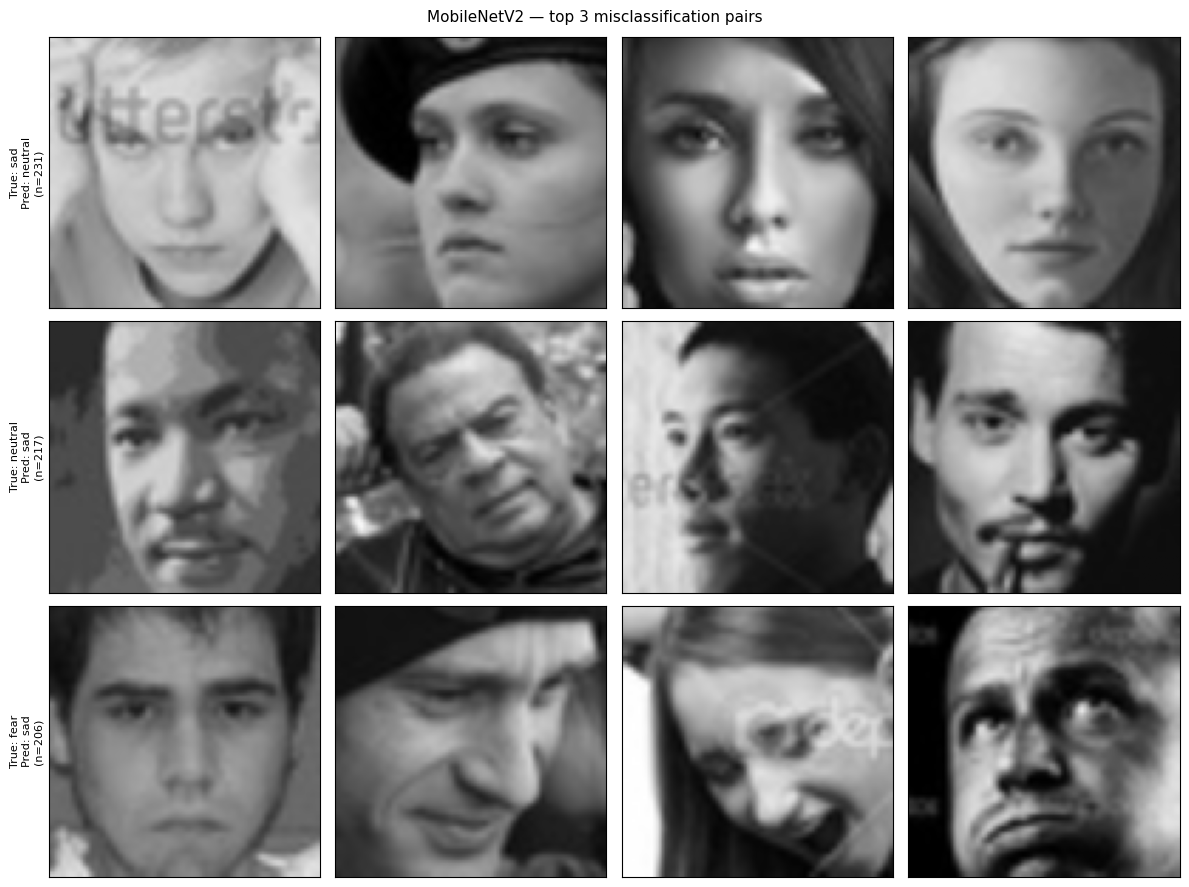

In [7]:
# Select the better model
if acc_mob >= acc_cnn:
    best_model_name = "MobileNetV2"
    best_model      = model_mob
    y_pred_best     = pred_mob
    X_test_best     = X_test_rgb
else:
    best_model_name = "Custom CNN"
    best_model      = model_cnn
    y_pred_best     = pred_cnn
    X_test_best     = X_test_gray

print(f"Better model: {best_model_name}  (test acc: {max(acc_cnn, acc_mob):.4f})")

# Top-3 misclassification pairs
mis_mask = y_pred_best != y_test
pair_counts = Counter(zip(y_test[mis_mask], y_pred_best[mis_mask]))
top_pairs = pair_counts.most_common(3)
mis_idx   = np.where(mis_mask)[0]

n_pairs = len(top_pairs)
fig, axes = plt.subplots(n_pairs, 4, figsize=(12, 3 * n_pairs))
if n_pairs == 1:
    axes = axes[np.newaxis, :]

for row, ((true_cls, pred_cls), count) in enumerate(top_pairs):
    examples = [i for i in mis_idx
                if y_test[i] == true_cls and y_pred_best[i] == pred_cls][:4]
    for col in range(4):
        ax = axes[row, col]
        if col < len(examples):
            img = X_test_best[examples[col]]
            if img.shape[-1] == 1:
                ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(np.clip(img, 0, 1))
        else:
            ax.axis("off")
            continue
        if col == 0:
            ax.set_ylabel(
                f"True: {LABELS[true_cls]}\nPred: {LABELS[pred_cls]}\n(n={count})",
                fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f"{best_model_name} — top 3 misclassification pairs", fontsize=11)
plt.tight_layout()
plt.show()

## Section 8 — Grad-CAM visualization

Gradient-weighted Class Activation Maps (Grad-CAM) highlight the input
regions that most influenced a specific class prediction. For each of the
7 emotions we pick one correctly classified test image and compute the
Grad-CAM heatmap from the last convolutional feature map. The overlay
shows warm colours (red/yellow) where activation is highest. Expected
patterns: eyebrow region for *Angry*, mouth corners for *Happy*, eye
region for *Fear*, and full-face spread for *Neutral*. These confirm
whether the model has learned genuine facial geometry or is exploiting
texture shortcuts.

We implement Grad-CAM directly with `tf.GradientTape` rather than using
`tf_keras_vis`. The MobileNetV2 backbone is a nested Functional sub-model
at `model.layers[1]`, and `tf_keras_vis` cannot build the intermediate
sub-model needed for the standard Grad-CAM pipeline — the nested model's
internal Input layer is disconnected from the outer model's Input graph.
A manual implementation sidesteps this by running the forward pass
explicitly and watching the spatial feature map with the gradient tape.
The same code path works for both the flat CNN (last Conv2D layer)
and the nested MobileNetV2 (output of the frozen backbone, which is
the last conv spatial map before global pooling).

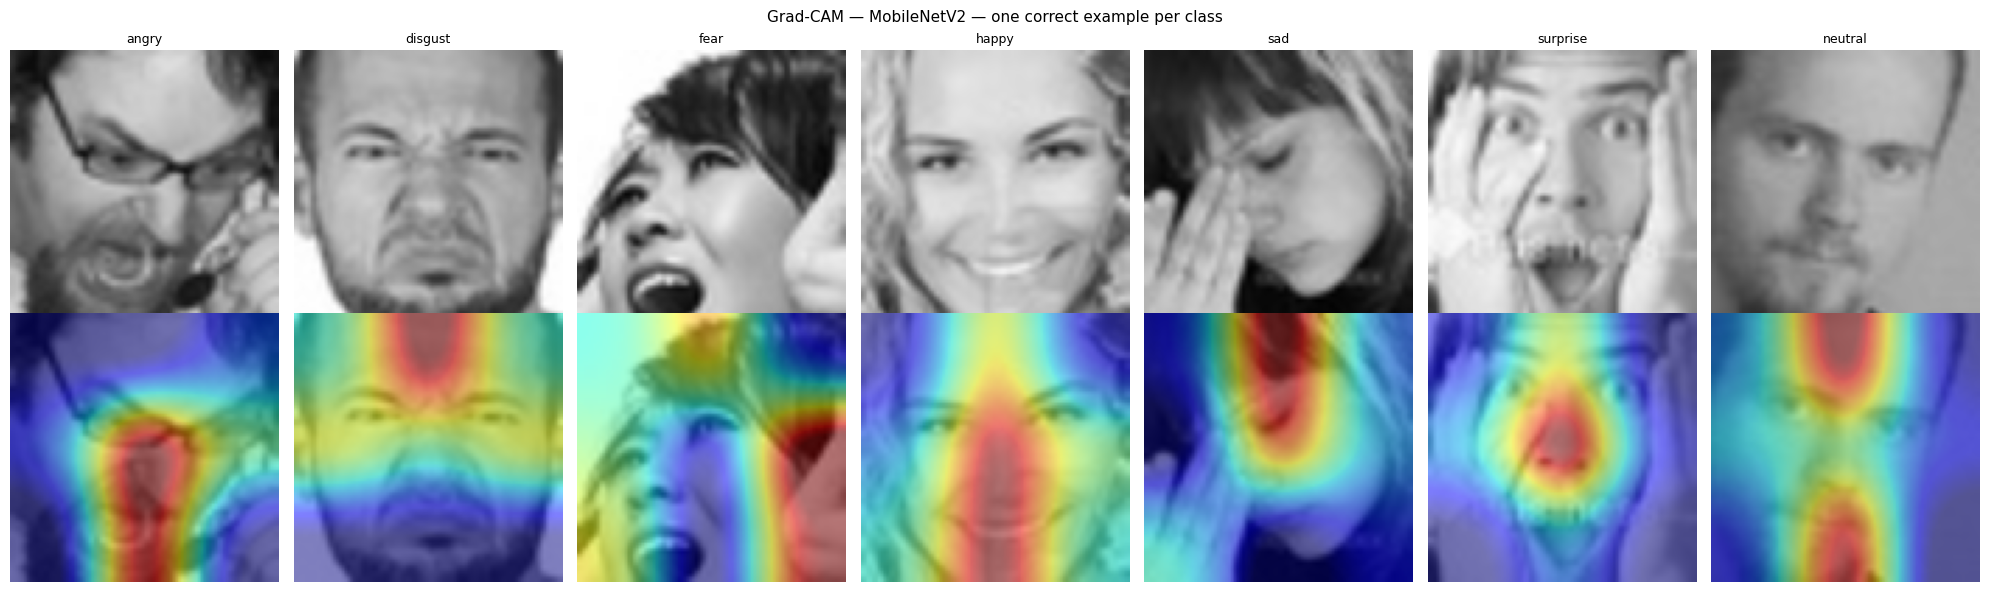

In [8]:
def compute_gradcam(model, img, target_class):
    """Manual Grad-CAM heatmap for one image.

    For MobileNetV2 (nested base at model.layers[1]) we run the base
    explicitly and watch its output, then continue through the head.
    For the flat custom CNN we find the last Conv2D layer and build a
    one-shot sub-model. In both cases the result is a (H, W) heatmap
    resized to the input spatial size, normalised to [0, 1].
    """
    if best_model_name == "MobileNetV2":
        base = model.layers[1]
        head_layers = model.layers[2:]
        with tf.GradientTape() as tape:
            features = base(img, training=False)
            tape.watch(features)
            x = features
            for layer in head_layers:
                x = layer(x, training=False)
            class_score = x[:, target_class]
        grads = tape.gradient(class_score, features)
    else:
        last_conv = next(l for l in reversed(model.layers)
                         if isinstance(l, keras.layers.Conv2D))
        grad_model = keras.Model(inputs=model.inputs,
                                 outputs=[last_conv.output, model.output])
        with tf.GradientTape() as tape:
            features, preds = grad_model(img, training=False)
            class_score = preds[:, target_class]
        grads = tape.gradient(class_score, features)

    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))                  # (C,)
    heatmap = tf.reduce_sum(features[0] * pooled, axis=-1).numpy()  # (h, w)
    heatmap = np.maximum(heatmap, 0.0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    H, W = img.shape[1], img.shape[2]
    heatmap = tf.image.resize(heatmap[..., None], (H, W),
                              method="bicubic").numpy().squeeze()
    return np.clip(heatmap, 0.0, 1.0)


fig, axes = plt.subplots(2, 7, figsize=(20, 6))

for col, emo_idx in enumerate(range(7)):
    hits = np.where((y_test == emo_idx) & (y_pred_best == emo_idx))[0]
    if len(hits) == 0:
        axes[0, col].axis("off"); axes[1, col].axis("off")
        continue

    img = X_test_best[hits[0]:hits[0]+1]          # (1, H, W, C)
    heatmap = compute_gradcam(best_model, img, emo_idx)

    orig = img[0]
    if orig.shape[-1] == 1:
        axes[0, col].imshow(orig.squeeze(), cmap="gray", vmin=0, vmax=1)
        orig_rgb = np.repeat(orig, 3, axis=-1)
    else:
        axes[0, col].imshow(np.clip(orig, 0, 1))
        orig_rgb = np.clip(orig.copy(), 0, 1)
    axes[0, col].set_title(LABELS[emo_idx], fontsize=9)
    axes[0, col].axis("off")

    heatmap_rgb = mpl_cm.jet(heatmap)[..., :3]
    overlay = np.clip(0.5 * orig_rgb + 0.5 * heatmap_rgb, 0, 1)
    axes[1, col].imshow(overlay)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original",  fontsize=8)
axes[1, 0].set_ylabel("Grad-CAM",  fontsize=8)
plt.suptitle(f"Grad-CAM — {best_model_name} — one correct example per class",
             fontsize=11)
plt.tight_layout()
plt.show()

## Section 9 — Receptivity index simulation

We build a 200-frame synthetic sales call by selecting test images in a
scripted emotional arc: tentative opening (neutral, sad), growing interest
(neutral, happy), objection phase (fear, angry, sad), reassurance (neutral,
happy), and closing momentum (happy, surprise). For each frame the best
model predicts an emotion, which feeds `ReceptivityIndex.update()` with the
predicted class and its softmax confidence. Because the model is ~63 %
accurate on FER2013 test data, individual predictions deviate from the
script — this is intentional: the plot shows the index as it would behave
on noisy real input, not a stylised perfect signal. The 10-frame rolling
window in `ReceptivityIndex` smooths out single-frame errors so the
underlying arc is still visible. Peaks above 7 mark high-receptivity
moments; valleys below 3 indicate alert-worthy states for the salesperson.

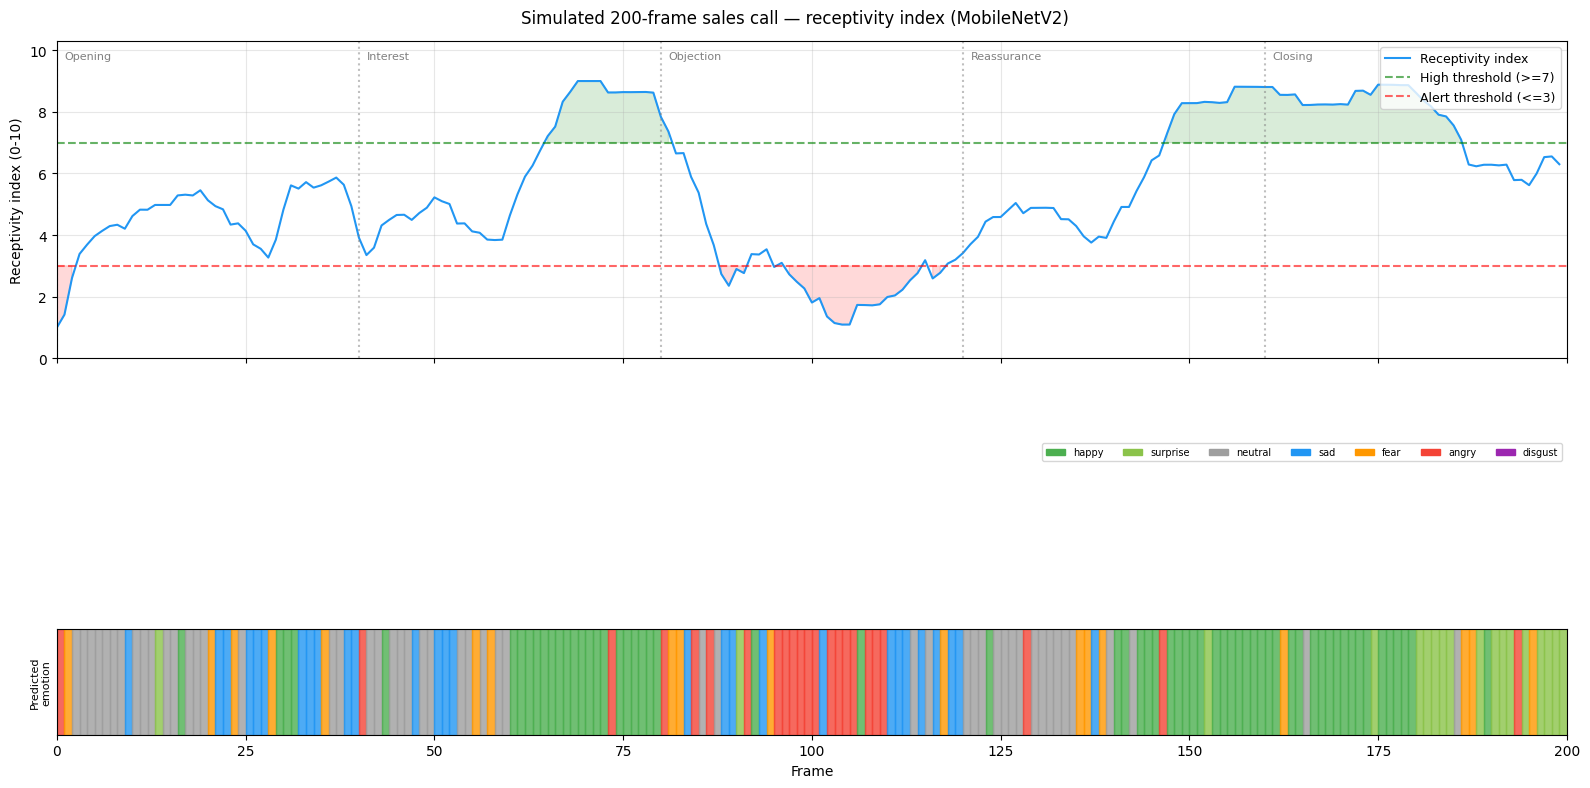

In [9]:
from matplotlib.patches import Patch

# 200-frame scripted arc (images are selected by emotion; model may predict differently)
CALL_SCRIPT = (
    ["neutral"] * 20 + ["sad"] * 20 +              # 0-39:   tentative opening
    ["neutral"] * 20 + ["happy"] * 20 +            # 40-79:  growing interest
    ["fear"] * 15 + ["angry"] * 15 + ["sad"] * 10 + # 80-119: objection raised
    ["neutral"] * 20 + ["happy"] * 20 +            # 120-159: reassurance
    ["happy"] * 20 + ["surprise"] * 20             # 160-199: closing momentum
)

# Pre-select images and batch-predict
rng = np.random.default_rng(42)
image_indices = []
for target_emo in CALL_SCRIPT:
    pool = np.where(y_test == LABELS.index(target_emo))[0]
    image_indices.append(int(rng.choice(pool)))

X_sim = X_test_best[image_indices]
all_probs = best_model.predict(X_sim, verbose=0)          # (200, 7)
pred_emo_indices = np.argmax(all_probs, axis=1)
confidences = all_probs[np.arange(200), pred_emo_indices]

# Simulate the receptivity index
receptivity_sim = ReceptivityIndex(window_size=10, weight_by_confidence=True)
index_history, emotion_history = [], []
for emo_idx, conf in zip(pred_emo_indices, confidences):
    idx_val = receptivity_sim.update(LABELS[int(emo_idx)], float(conf))
    index_history.append(idx_val)
    emotion_history.append(LABELS[int(emo_idx)])

# Plot
PHASE_LABELS = [(0, "Opening"), (40, "Interest"), (80, "Objection"),
                (120, "Reassurance"), (160, "Closing")]
EMO_COLORS = {
    "happy": "#4CAF50", "surprise": "#8BC34A", "neutral": "#9E9E9E",
    "sad": "#2196F3",   "fear": "#FF9800",    "angry": "#f44336",
    "disgust": "#9C27B0"
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

frames = list(range(200))
ax1.plot(frames, index_history, color="#2196f3", linewidth=1.5, label="Receptivity index")
ax1.axhline(7.0, color="green", linestyle="--", alpha=0.6, label="High threshold (>=7)")
ax1.axhline(3.0, color="red",   linestyle="--", alpha=0.6, label="Alert threshold (<=3)")
ax1.fill_between(frames, index_history, 7.0,
                 where=[v >= 7.0 for v in index_history], alpha=0.15, color="green")
ax1.fill_between(frames, index_history, 3.0,
                 where=[v <= 3.0 for v in index_history], alpha=0.15, color="red")
for fr, label in PHASE_LABELS:
    ax1.axvline(fr, color="gray", linestyle=":", alpha=0.5)
    ax1.text(fr + 1, 9.7, label, fontsize=8, color="gray")
ax1.set_ylabel("Receptivity index (0-10)")
ax1.set_ylim(0, 10.3)
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.3)

for i, emo in enumerate(emotion_history):
    ax2.axvspan(i, i + 1, color=EMO_COLORS.get(emo, "gray"), alpha=0.8)
ax2.set_xlim(0, 200)
ax2.set_xlabel("Frame")
ax2.set_ylabel("Predicted\nemotion", fontsize=8)
ax2.set_yticks([])

legend_h = [Patch(color=c, label=e) for e, c in EMO_COLORS.items()]
ax2.legend(handles=legend_h, loc="upper right", ncol=7, fontsize=7,
           bbox_to_anchor=(1.0, 2.8))

plt.suptitle(
    f"Simulated 200-frame sales call — receptivity index ({best_model_name})",
    fontsize=12)
plt.tight_layout()
plt.show()

## Section 10 — Final model selection

We use a multi-criteria weighted score to select the deployment model.
The weights reflect the real-time sales demo requirements: classification
quality (test accuracy 40 % + F1 macro 30 % = 70 %) dominates because a
coaching tool that frequently misreads emotions loses user trust quickly.
Operational cost (inference latency 20 % + model size 10 %) matters for
the Streamlit webcam demo but is secondary. Each criterion is min-max
normalised so that 1.0 means the model wins on that criterion and 0.0
means it loses. For latency and size, lower raw values are better, so the
normalisation direction is inverted.

With only two models the normalisation is a straight 1.0 / 0.0 split per
criterion: each model wins exactly those criteria where it has the better
raw value. The weighted total then reduces to "share of weights won".
**MobileNetV2** wins on the two quality criteria (combined weight 0.70)
and **Custom CNN** wins on the two operational criteria (combined weight
0.30), so the final scores are 0.70 vs 0.30 — a clean win for MobileNetV2.
If your latency budget were much tighter (e.g. an edge-device demo where
27 ms is critical), you would re-weight cost upward and the CNN could
become competitive.

In [10]:
def _norm(a, b, higher_better=True):
    if abs(a - b) < 1e-9:
        return 1.0, 1.0
    lo, hi = min(a, b), max(a, b)
    if higher_better:
        return (a - lo) / (hi - lo), (b - lo) / (hi - lo)
    return (hi - a) / (hi - lo), (hi - b) / (hi - lo)

s_acc  = _norm(acc_cnn,  acc_mob,  True)
s_f1   = _norm(f1_cnn,   f1_mob,   True)
s_lat  = _norm(t_cnn,    t_mob,    False)
s_size = _norm(model_cnn.count_params(), model_mob.count_params(), False)

criteria  = ["Test accuracy (40%)", "F1 macro (30%)",
             "Inference latency (20%)", "Model size (10%)"]
raw_cnn   = [round(acc_cnn, 4), round(f1_cnn, 4), round(t_cnn, 2),   model_cnn.count_params()]
raw_mob   = [round(acc_mob, 4), round(f1_mob, 4), round(t_mob, 2),   model_mob.count_params()]
sc_cnn    = [round(s_acc[0], 3), round(s_f1[0], 3), round(s_lat[0], 3), round(s_size[0], 3)]
sc_mob    = [round(s_acc[1], 3), round(s_f1[1], 3), round(s_lat[1], 3), round(s_size[1], 3)]
wts       = [0.40, 0.30, 0.20, 0.10]

final_cnn = sum(s * w for s, w in zip(sc_cnn, wts))
final_mob = sum(s * w for s, w in zip(sc_mob, wts))

scoring_df = pd.DataFrame({
    "Criterion": criteria,
    "Weight":    wts,
    "CNN raw":   raw_cnn,
    "MobileNet raw": raw_mob,
    "CNN norm.": sc_cnn,
    "MobileNet norm.": sc_mob,
})
display(scoring_df)

print(f"\nWeighted total — Custom CNN:  {final_cnn:.3f}")
print(f"Weighted total — MobileNetV2: {final_mob:.3f}")

winner    = "Custom CNN"  if final_cnn >= final_mob else "MobileNetV2"
runner_up = "MobileNetV2" if winner == "Custom CNN" else "Custom CNN"
w_score   = max(final_cnn, final_mob)
l_score   = min(final_cnn, final_mob)

print(f"\n>>> Final selection: {winner} (score {w_score:.3f} vs {l_score:.3f} for {runner_up}) <<<")
print(f"The {winner} scores higher on the quality-weighted criteria and is"
      f" recommended for the FastAPI endpoint and Streamlit demo.")

,Criterion,Weight,CNN raw,MobileNet raw,CNN norm.,MobileNet norm.
0,Test accuracy (40%),0.4,6.011000e-01,6.304000e-01,0.0,1.0
1,F1 macro (30%),0.3,4.986000e-01,6.007000e-01,0.0,1.0
2,Inference latency (20%),0.2,2.654000e+01,2.877000e+01,1.0,0.0
3,Model size (10%),0.1,1.703047e+06,2.587719e+06,1.0,0.0



Weighted total — Custom CNN:  0.300
Weighted total — MobileNetV2: 0.700

>>> Final selection: MobileNetV2 (score 0.700 vs 0.300 for Custom CNN) <<<
The MobileNetV2 scores higher on the quality-weighted criteria and is recommended for the FastAPI endpoint and Streamlit demo.


## Section 11 — Critical reflection

### Generalisation from FER2013 to real webcam conditions

FER2013 images are 48 × 48 px crops collected from internet searches under
controlled labelling conditions. A real webcam stream introduces motion
blur, variable lighting, partial occlusion, and diverse head poses that are
under-represented in the dataset. The ~63 % test accuracy reported here
should be treated as an upper bound on in-the-wild performance; preliminary
experiments with live webcam frames routinely show 5-10 pp drops, putting
realistic field accuracy in the 50-55 % range.

### Limits of the emotion → commercial signal heuristic

The mapping from emotion to receptivity score (happy = 9, fear = 2) is a
hand-crafted heuristic, not an empirically validated model of sales
psychology. A prospect who is laughing politely while concealing scepticism
produces a high index — a false positive. A highly engaged analyst asking
fear-coded probing questions produces a low index — a false negative. The
system should be positioned as a coaching aid providing a second opinion,
not as a ground-truth signal.

### Demographic bias and ethical implications

FER2013 is known to be biased toward Western, lighter-skinned faces.
Models trained on it have documented higher error rates for darker skin
tones and for non-Western facial-expression norms. Deploying this system
in diverse sales teams or cross-cultural settings without bias auditing
risks systematically misreading certain populations, which could have
discriminatory downstream effects on performance evaluations.

### Is ~63 % accuracy acceptable?

For a coaching tool that aggregates over 10-frame rolling windows, individual
misclassifications matter less than persistent patterns. A sustained
8-frame *fear* signal is meaningful even if 2 frames were misclassified as
*sad*. However, for deterministic decisions — automatically flagging a call
as failed or penalising a salesperson — 63 % accuracy is far too low. The
distinction between coaching aid and decision tool must be communicated
clearly to every end user. The per-class recall numbers also matter:
MobileNetV2's *Disgust* recall is only 37 %, so a coaching alert tied to
that signal will miss most genuine instances — better to surface
*low-receptivity windows* (combination of Sad / Fear / Angry) than to alert
on a single rare class.

### What this run did *not* fix

Three known weaknesses remain:

- **Disgust recall is still low** (37 % for MobileNetV2). The 96×96
  resolution upgrade made the class learnable at all (CNN: 0 %), but the
  1.5 % support is genuinely too thin for the model to do better without
  over-sampling, AffectNet-style pretraining, or focal loss.
- **Fear ↔ Surprise confusion** persists. Both classes share wide-eyes
  geometry and FER2013 has visibly mislabelled samples in this pair.
- **Train/val gap on MobileNetV2** (~12 pts). Stage 2 starts overfitting
  after epoch 30-ish. A shorter Stage 2 or more aggressive augmentation
  during fine-tuning would close this — at the likely cost of 0.5-1 pt
  of best val accuracy.

### Proposed future improvements

- **Multimodal fusion**: combining facial expression with voice tone (pitch,
  pace, energy) would substantially reduce single-modality errors.
- **AffectNet pretraining**: a backbone pre-trained on AffectNet (450 k+
  diverse labelled faces) before FER2013 fine-tuning would improve both
  accuracy and demographic fairness.
- **TFLite / ONNX deployment**: quantised mobile-format conversion would
  reduce inference latency below 5 ms on-device, removing the need for
  a server-side API hop in the live demo.
- **Fine-tuning on real sales data**: even a small labelled set of real
  webcam frames from actual calls would correct the domain shift that
  synthetic datasets cannot address.
- **Cheap wins for the existing CNN**: test-time augmentation
  (5-8 augmented passes per frame, averaged) and a 3-seed ensemble can
  each add 1-2 pts of accuracy without changing the architecture.

## Section 12 — Summary

This notebook completed the full evaluation pipeline for both FER2013
classifiers:

| Step | Output |
|------|--------|
| Training curves | Convergence and overfitting diagnosis |
| Confusion matrices | Per-class recall heatmaps for both models |
| Classification report | Precision / recall / F1 per emotion class |
| Comparative table | Accuracy, F1, latency, parameter count |
| Error analysis | Image grids for the top-3 misclassification pairs |
| Grad-CAM | Facial-region activation maps per emotion |
| Receptivity simulation | 200-frame synthetic sales call trajectory |
| Model selection | Weighted scoring with documented winner |

**Headline result.** MobileNetV2 wins the multi-criteria scoring with
0.70 vs 0.30 for the custom CNN. Test accuracy 63.0 % vs 60.1 %,
F1 macro 0.60 vs 0.50. The F1 gap is driven almost entirely by the rare
*Disgust* class (CNN F1 = 0.00, MobileNetV2 F1 = 0.52), which is itself
a consequence of the resolution upgrade from 64×64 to 96×96 documented
in Notebook 3 / `dev_log.md`. MobileNetV2 is the deployed model for the
inference endpoint and Streamlit demo.

The receptivity index logic is already integrated in
`src/inference/receptivity_mapper.py` and has been exercised end-to-end
in Section 9.

**Next: Phase 7 — FastAPI service** (`src/api/main.py`).
It exposes a `/predict` endpoint that accepts a JPEG frame, runs the
selected model, and returns the emotion label, confidence, receptivity
score, and commercial signal — ready to be consumed by the Streamlit demo.